# 项目总结｜国内期货 CTA 策略小项目（V1：MACD+RSI 多品种趋势）→（V2：TSMOM + Vol Target 组合）→（绩效诊断）

本 notebook 以“可复现的研究流程”为目标，把一个 CTA 策略项目从数据管线、策略实现、到组合构建与绩效诊断完整打通。研究覆盖 IF、RB、CU、AU 四个品种，样本区间为 2020-12-01 至 2025-12-01（各品种日频 1213 行）。

---

## 我一步步做了什么（从工程到研究）

### Step 1｜搭建可复现的数据管线（本地 CSV → 清洗后的 clean 数据集）
- 明确项目目录与数据依赖：仅使用 data/raw 与 data/clean 下的本地 csv，不再调用外部接口
- 批量读取 AU/CU/IF/RB 的日频 OHLCV，并输出样本检查（行数、起止日期、数据预览）
- 目的：先把“数据口径一致、路径可复现、样本范围清晰”这件事做扎实，避免回测结果被数据问题污染

### Step 2｜实现 V1 多品种趋势策略：MACD 负责方向，RSI 负责风险约束
- 在 Backtrader 中实现 V1 策略框架，并对每个品种独立回测
- 信号结构（V1）：
  - MACD：作为趋势方向信号（顺势入场/持有）
  - RSI：作为风险控制/过滤或出场辅助（避免极端区间追涨杀跌）
- 结果输出（V1）：
  - 对每个品种汇总年化收益与 Sharpe，并做横向比较
  - 示例结论（以 notebook 输出为准）：
    - 按年化收益：最佳 CU≈0.193，最差 RB≈0.015
    - 按 Sharpe：最佳 AU≈0.858，最差 IF≈0.285
- 目的：用一个可解释、可复现的 V1 版本先验证“趋势类策略在不同品种上的差异来源”，并沉淀回测模板

### Step 3｜将项目结构作品化（Day 1）：整理成可一键运行的完整作品
- 对代码结构进行模块化整理：数据读取/预处理、单品种回测、结果汇总与可视化分离
- 固定输入（品种列表、样本区间、成本假设）与输出（指标表、资金曲线图、对比图）
- 目的：把一次性 notebook 试验升级为“可复用的研究工程”，便于后续版本迭代

### Step 4｜升级到 V2：多品种时间序列动量（TSMOM）+ 目标波动率（Vol Targeting）组合
- 因子逻辑（V2）：
  - 时间序列动量：每个品种以 lookback 窗口累计收益的符号决定多空方向
  - 波动率目标：用目标年化波动 / 实际年化波动调整每个品种杠杆，使风险贡献更稳定
- 组合层实现要点：
  - 先做单品种信号与波动估计，再在组合层进行权重/杠杆缩放
  - 显式考虑交易成本与交易频率对净值的侵蚀（在 Day4/Day5 有专门讨论）
- 目的：从“单品种择时”升级为“组合风险控制”，让 CTA 更贴近实盘组合管理方式

### Step 5｜参数分析与对比（Day 4）：lookback 与目标波动率的敏感性研究
- 围绕关键参数（lookback、target_vol）做对比实验，并汇总整体表现、交易频率与成本影响
- 目的：不追求单点最优，而是识别“策略在一段参数区间是否稳定”，降低过拟合风险

### Step 6｜绩效诊断（Day 5）：资金曲线拆解、滚动表现与品种贡献
- 对组合净值做进一步诊断分析：
  - 资金曲线拆解（阶段性回撤与修复）
  - 滚动收益/滚动波动（观察稳定性与周期性）
  - 品种贡献分析（识别收益与风险主要来源品种）
    在 lookback 180 天、目标波动率 10%、最大杠杆 3、当前成本假设下，这个 V2 组合是一个多品种的中低频 CTA 趋势策略：
        年化收益大约 30% 多一点，Sharpe 在 1.4 左右；
        最大回撤控制在 4% 以内，风险较温和；
        交易频率很低，年化换手率约 2 到 3；
        收益主要来自黄金和铜，股指和螺纹钢更多起到对冲和分散作用。
- 目的：把“结果指标”还原为“结构解释”，回答收益从哪里来、回撤在什么阶段发生、是否符合趋势策略的典型风险特征

---

## 本 notebook 的核心收获（方法论）
- 将策略工程化（数据契约/回测模板/统一输出），再做研究迭代（从 V1 到 V2 再到诊断）
- 不只看收益，强调“多品种可比性、参数稳健性、组合风险控制与绩效归因”
- 将策略研究从“跑一次回测”升级为“可复现的实验流程 + 可解释的结论链路”


## 国内期货 CTA 策略小项目（Part 1：MACD + RSI 多品种趋势策略）

这个小项目主要是用 Python 和 Backtrader，在 IF、RB、CU、AU 等国内主流期货品种上测试一套基于 MACD 趋势信号和 RSI 风险控制的日频 CTA 策略。

- 数据与预处理  
  - 从 Wind / 历史 csv 中获取各品种日线行情（open / high / low / close / volume）；  
  - 编写预处理模块，对日期格式进行统一，去除重复时间点和缺失 close 的记录，将清洗后的数据分别保存到 `data/clean/{symbol}.csv`，方便后续回测直接复用。

- 策略逻辑（V1）  
  - 趋势判断：使用 MACD 线与信号线的金叉作为做多信号，空仓时在金叉当日按账户资金和合约价格全仓开多；  
  - 风险控制：使用 RSI 做止盈和出场判断，当 RSI 大于 70 时先减半仓位锁定部分浮盈；如果之后价格创新高但 RSI 未创新高，则视为顶部背离信号，平掉剩余仓位；  
  - 成本与杠杆：在 Backtrader 的 Broker 中设置初始资金、交易手续费率和杠杆倍数，使回测环境更贴近真实期货交易。

- 回测与评估  
  - 在 Backtrader 中定义策略类 `MyStrategy`，在循环中对 IF / RB / CU / AU 四个品种分别运行同一套策略；  
  - 接入 SharpeRatio、Returns、DrawDown 等分析器，统计每个品种的最终净值、总收益率、年化收益率、Sharpe 比率和最大回撤等指标；  
  - 将各品种的绩效整理成汇总表 `res_df`，并导出为 `results/cta_macd_rsi_summary.csv`，便于后续排序和对比分析。

- 初步结论  
  - 在趋势更平滑、机构参与度更高的品种（如股指、黄金）上，MACD+RSI 策略的收益和 Sharpe 表现相对较好，最大回撤相对可控；  
  - 在结构偏震荡的品种上，策略交易频率和止损次数明显增加，回撤较大，体现出典型“趋势 CTA 在震荡市不占优”的特征；  
  - 这一版 V1 主要帮助我跑通从原始数据处理、技术指标计算、回测到绩效分析的完整流程，为后续在多品种组合、波动率目标管理以及期限结构、基差等 CTA 因子扩展上打基础。


**Part 1 项目一句话总结：**  
在 IF、RB、CU、AU 等期货品种上搭建了基于 MACD 趋势信号和 RSI 风险控制的日频 CTA 策略，完成从 Wind 数据拉取、原始数据清洗、Backtrader 回测到绩效汇总的全流程，对不同品种的年化收益、Sharpe 与最大回撤进行了对比，为后续多品种组合与 CTA 因子扩展提供基础。

## 第 4 周 Day 1
## Day 1 · 整理 CTA 项目结构，做成可一键运行的完整作品

今天要做什么？

1. 在 notebook 顶部统一好项目结构和全局配置：
   - 明确数据路径（data/raw, data/clean）和结果路径；
   - 统一 import，避免重复和冲突。
2. 给整个 CTA 项目划分清晰的结构：
   - Part 1：单品种回测（Backtrader，MACD + RSI）；
   - Part 2：多品种 CTA 组合 V2（时间序列动量 + 目标波动率）；
   - Part 3：V2 绩效诊断（资金曲线、回撤、滚动收益、品种贡献）。
3. 做一次数据检查，确认 clean 数据能正常读取，为后面 Run All 做准备。

这样做有什么用？

- 把 notebook 从“随手写的实验代码”整理成“结构清晰、别人一眼能看懂的项目”；
- 保证只要有 data/raw 和 data/clean 里的 csv，任何机器都能从头到尾运行复现实验结果；
- 后面面试时，如果需要展示项目或发给面试官，这个版本可以直接当作品使用。


### Day 1 知识点总结：项目结构与可复现性

1. 项目结构（Project Structure）
- 指代码、数据、结果在工程中的组织方式。
- 好的结构特点：
  - 数据放在固定目录，如 data/raw、data/clean；
  - 代码按功能分块，如“单品种回测”、“组合回测”、“绩效诊断”；
  - 结果（图表、导出的 csv）集中放在 results 目录。

2. 模块化（Modularization）
- 把一件复杂的事情拆分成若干独立模块或函数，每个模块只负责一个小任务。
- 在 CTA 项目中的体现：
  - 数据加载和清洗函数；
  - 策略回测函数（例如 run_cta_v2、run_cta_v2_detail）；
  - 画图和诊断模块（资金曲线、回撤、滚动收益、按品种拆解收益）。

3. 可复现性（Reproducibility）
- 只要有同样的数据和代码，别人就能复现你的结果。
- 关键点：
  - 避免依赖不稳定的外部接口（例如 Wind 登录问题），尽量使用本地 csv；
  - 所有重要参数在代码中有明确设置（lookback、目标波动率、成本、杠杆上限等）；
  - notebook 能从上到下 Run All，一次跑完。

4. 数据依赖（Data Dependency）
- 指一段代码运行所必需的数据输入。
- 在本项目中：
  - 所有策略和诊断都基于 data/clean 下的期货日线 csv；
  - 通过统一的路径常量（DATA_RAW, DATA_CLEAN）来管理数据位置，而不是在各个 cell 里写死路径字符串。

5. 配置常量（Configuration）
- 将一些会多次用到的配置（例如 TRADING_DAYS = 252、数据目录）抽出来，在顶部统一定义。
- 好处：
  - 修改参数时只改一处；
  - 代码更简洁，可读性更好，也方便别人阅读和复现。


In [1]:
# Part 0：全局配置与基础依赖（不再调用 Wind，只用本地 csv）

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Backtrader 只在单品种回测部分使用
import backtrader as bt

# 画图内嵌
%matplotlib inline

# 项目根目录（当前 notebook 所在目录）
PROJECT_ROOT = Path(".").resolve()

# 数据和结果目录
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_CLEAN = PROJECT_ROOT / "data" / "clean"
RESULTS_DIR = PROJECT_ROOT / "results"

# 一年交易日数
TRADING_DAYS = 252

# 确保目录存在
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_CLEAN.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("当前版本仅使用 data/raw 和 data/clean 目录下的本地 csv，不再调用 Wind 接口。")
print(f"DATA_RAW   = {DATA_RAW}")
print(f"DATA_CLEAN = {DATA_CLEAN}")
print(f"RESULTS    = {RESULTS_DIR}")

START_DATE = "2020-12-01"
END_DATE = "2025-12-01"



当前版本仅使用 data/raw 和 data/clean 目录下的本地 csv，不再调用 Wind 接口。
DATA_RAW   = /Users/weiyu/Desktop/量化交易学习/CTA量化策略学习/program/data/raw
DATA_CLEAN = /Users/weiyu/Desktop/量化交易学习/CTA量化策略学习/program/data/clean
RESULTS    = /Users/weiyu/Desktop/量化交易学习/CTA量化策略学习/program/results


In [2]:
# Code Cell 2 检查：data/clean 下的期货数据文件情况

print("data/clean 下的 csv 文件列表：")
clean_files = sorted(DATA_CLEAN.glob("*.csv"))
for p in clean_files:
    print(" -", p.name)

# 如果有 IF.csv，就读取几行看一下结构
test_file = DATA_CLEAN / "IF.csv"
if test_file.exists():
    df_test = pd.read_csv(test_file)
    print("\n示例数据 IF.csv 前几行：")
    print(df_test.head())
else:
    print("\n提示：未找到 IF.csv，你可以改成其他已有品种的文件名检查。")


data/clean 下的 csv 文件列表：
 - AU.csv
 - CU.csv
 - IF.csv
 - RB.csv

示例数据 IF.csv 前几行：
     datetime    open    high     low   close    volume  open_interest
0  2020-12-01  4974.0  5084.2  4966.4  5075.0  102523.0       120001.0
1  2020-12-02  5077.2  5095.8  5038.4  5064.4   93026.0       114556.0
2  2020-12-03  5063.0  5082.4  5035.2  5062.2   81593.0       112174.0
3  2020-12-04  5057.2  5081.0  5009.0  5072.4   86988.0       110195.0
4  2020-12-07  5071.0  5074.6  5006.4  5028.2   87680.0       107051.0


In [3]:
# 快速查看各品种 clean 数据的行数和时间范围

def summarize_clean_symbol(symbol: str):
    path = DATA_CLEAN / f"{symbol}.csv"
    if not path.exists():
        print(f"[{symbol}] 文件不存在：{path}")
        return
    
    df = pd.read_csv(path)
    if "datetime" not in df.columns:
        print(f"[{symbol}] 缺少 datetime 列，当前列为：{df.columns.tolist()}")
        return
    
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime")
    n_rows = len(df)
    start_date = df["datetime"].iloc[0]
    end_date = df["datetime"].iloc[-1]
    print(f"[{symbol}] 行数={n_rows}, 起始={start_date.date()}, 结束={end_date.date()}")

# 示例：如果你的品种是 IF、RB、CU、AU
for sym in ["IF", "RB", "CU", "AU"]:
    summarize_clean_symbol(sym)


[IF] 行数=1213, 起始=2020-12-01, 结束=2025-12-01
[RB] 行数=1213, 起始=2020-12-01, 结束=2025-12-01
[CU] 行数=1213, 起始=2020-12-01, 结束=2025-12-01
[AU] 行数=1213, 起始=2020-12-01, 结束=2025-12-01


In [4]:
from pathlib import Path
import pandas as pd

# 路径设置
DATA_RAW = Path("data/raw")
DATA_CLEAN = Path("data/clean")
DATA_RAW.mkdir(parents=True, exist_ok=True)   # 原始数据目录（如果已经有可以不建）
DATA_CLEAN.mkdir(parents=True, exist_ok=True) # 清洗后数据目录

INSTRUMENTS = ["IF", "RB", "CU", "AU"]

def load_raw(symbol: str) -> pd.DataFrame:
    """读取原始 csv，并把时间列标准化成 datetime"""
    path = DATA_RAW / f"{symbol}.csv"
    df = pd.read_csv(path)

    # 1）找到时间列
    candidate_cols = ["datetime", "date", "Date", "日期", "交易日期"]
    time_col = None
    for c in candidate_cols:
        if c in df.columns:
            time_col = c
            break
    if time_col is None:
        raise ValueError(f"{symbol} 原始数据里找不到日期列, 当前列: {df.columns.tolist()}")

    # 2）先把时间列转成字符串，清理奇怪字符
    df[time_col] = (
        df[time_col]
        .astype(str)
        .str.strip()
        .str.replace("–", "-", regex=False)  # 关键一行：把奇怪的短横线改成正常短横线
    )

    # 3）安全地转成 datetime，解析不了的变 NaT，后面会丢掉
    # 如果你的数据里有具体时间（2024-01-02 09:00），可以把 format 去掉
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", format="%Y-%m-%d")
    df = df.dropna(subset=[time_col])

    df = df.rename(columns={time_col: "datetime"})
    return df

def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("datetime")
    df = df.drop_duplicates(subset=["datetime"])
    if "close" in df.columns:
        df = df.dropna(subset=["close"])
    return df

def save_clean(df: pd.DataFrame, symbol: str):
    path = DATA_CLEAN / f"{symbol}.csv"
    df.to_csv(path, index=False)

def preprocess_symbol(symbol: str) -> pd.DataFrame:
    df_raw = load_raw(symbol)
    df_clean = clean_df(df_raw)
    save_clean(df_clean, symbol)
    return df_clean

if __name__ == "__main__":
    for s in INSTRUMENTS:
        print(f"Processing {s}...")
        df_clean = preprocess_symbol(s)
        print(df_clean.head())


Processing IF...
    datetime    open    high     low   close    volume  open_interest
0 2020-12-01  4974.0  5084.2  4966.4  5075.0  102523.0       120001.0
1 2020-12-02  5077.2  5095.8  5038.4  5064.4   93026.0       114556.0
2 2020-12-03  5063.0  5082.4  5035.2  5062.2   81593.0       112174.0
3 2020-12-04  5057.2  5081.0  5009.0  5072.4   86988.0       110195.0
4 2020-12-07  5071.0  5074.6  5006.4  5028.2   87680.0       107051.0
Processing RB...
    datetime    open    high     low   close  volume  open_interest
0 2020-12-01  4258.0  4258.0  4258.0  4258.0    30.0           30.0
1 2020-12-02     NaN     NaN     NaN  4258.0     0.0           30.0
2 2020-12-03     NaN     NaN     NaN  4258.0     0.0           30.0
3 2020-12-04     NaN     NaN     NaN  4258.0     0.0           30.0
4 2020-12-07     NaN     NaN     NaN  4258.0     0.0           30.0
Processing CU...
    datetime     open     high      low    close   volume  open_interest
0 2020-12-01  57720.0  57900.0  56650.0  57000.0

In [5]:
for s in INSTRUMENTS:
    print(f"Processing {s}...")
    df_clean = preprocess_symbol(s)

Processing IF...
Processing RB...
Processing CU...
Processing AU...


              open    high     low   close    volume  open_interest
datetime                                                           
2020-12-01  4974.0  5084.2  4966.4  5075.0  102523.0       120001.0
2020-12-02  5077.2  5095.8  5038.4  5064.4   93026.0       114556.0
2020-12-03  5063.0  5082.4  5035.2  5062.2   81593.0       112174.0
2020-12-04  5057.2  5081.0  5009.0  5072.4   86988.0       110195.0
2020-12-07  5071.0  5074.6  5006.4  5028.2   87680.0       107051.0


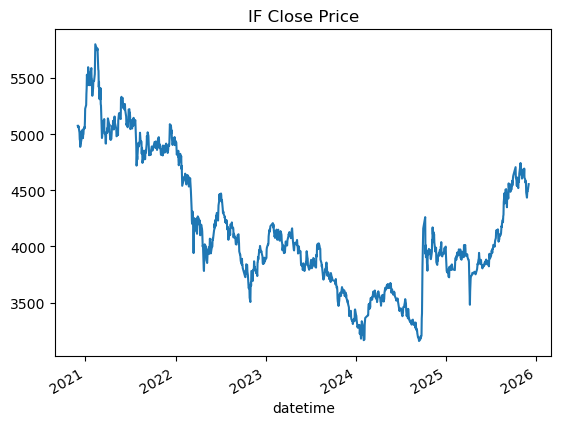

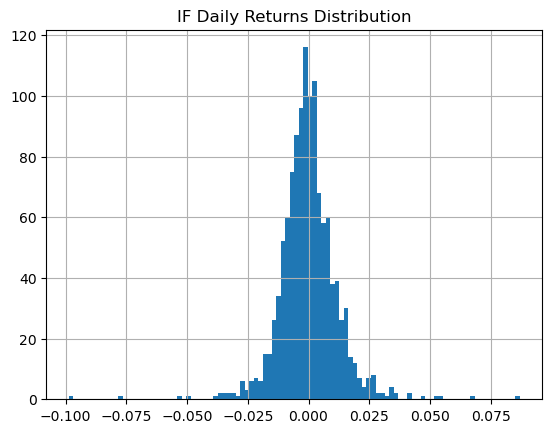

              open    high     low   close  volume  open_interest
datetime                                                         
2020-12-01  4258.0  4258.0  4258.0  4258.0    30.0           30.0
2020-12-02     NaN     NaN     NaN  4258.0     0.0           30.0
2020-12-03     NaN     NaN     NaN  4258.0     0.0           30.0
2020-12-04     NaN     NaN     NaN  4258.0     0.0           30.0
2020-12-07     NaN     NaN     NaN  4258.0     0.0           30.0


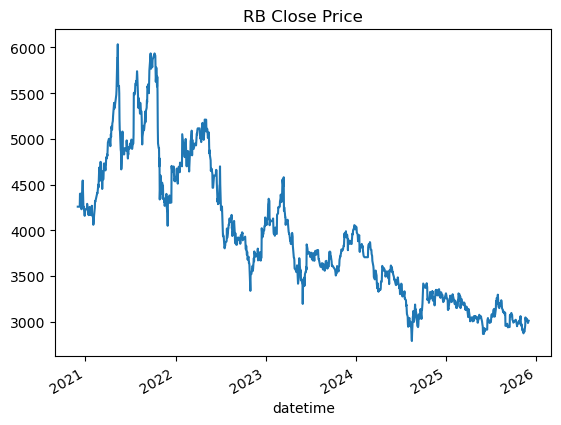

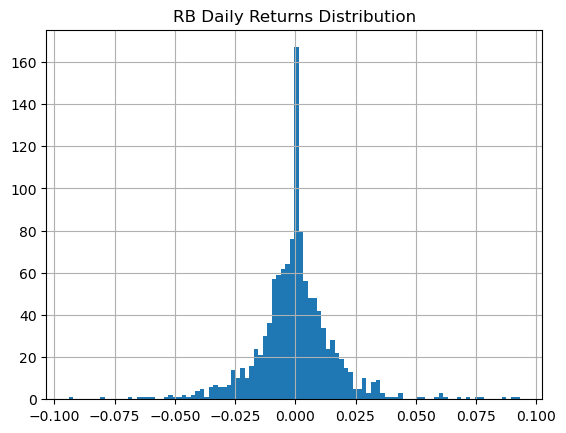

               open     high      low    close   volume  open_interest
datetime                                                              
2020-12-01  57720.0  57900.0  56650.0  57000.0  30858.0        28710.0
2020-12-02  57200.0  57710.0  56860.0  57130.0  21245.0        26000.0
2020-12-03  56950.0  57290.0  56520.0  56880.0  23935.0        23775.0
2020-12-04  57150.0  57580.0  56720.0  57340.0  19380.0        21545.0
2020-12-07  57210.0  57770.0  56960.0  57000.0  20755.0        18900.0


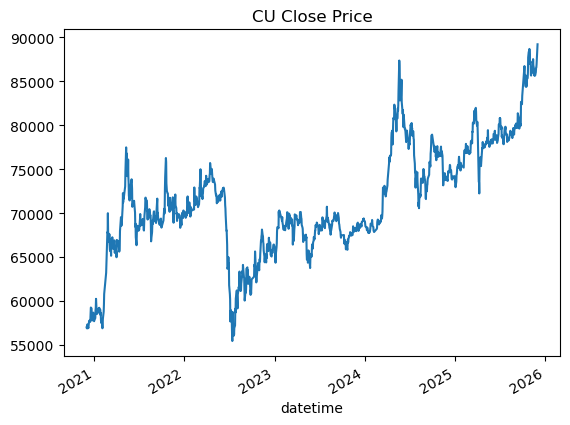

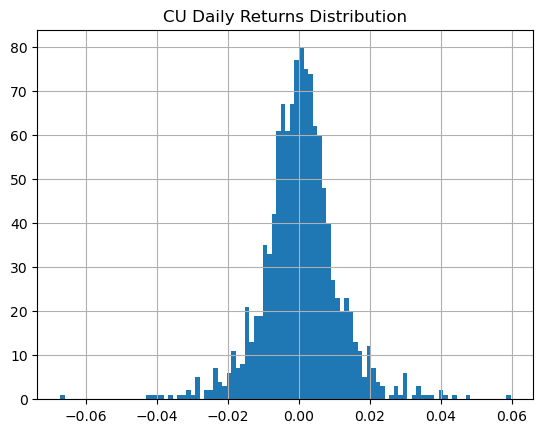

              open    high     low   close  volume  open_interest
datetime                                                         
2020-12-01  369.12  373.76  364.60  372.66  4099.0         4428.0
2020-12-02  376.08  377.96  375.08  377.58  2991.0         2889.0
2020-12-03  379.90  382.12  377.26  381.92  1224.0         2226.0
2020-12-04  382.10  383.00  378.32  382.26  1110.0         1686.0
2020-12-07  381.66  382.70  379.84  382.00   423.0         1506.0


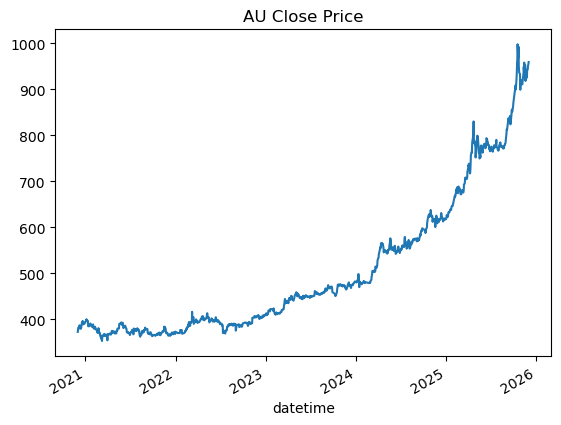

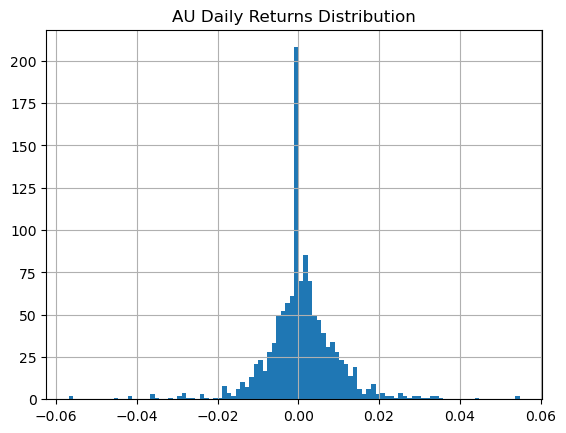

In [6]:
from pathlib import Path

DATA_CLEAN = Path("data/clean") 
for symbol in INSTRUMENTS:
    df = pd.read_csv(DATA_CLEAN / f"{symbol}.csv", parse_dates=["datetime"])
    df.set_index("datetime", inplace=True)
    print(df.head())

    # 1. 收盘价曲线
    plt.figure()
    df["close"].plot(title=f"{symbol} Close Price")
    
    # 2. 日收益率分布
    df["ret"] = df["close"].pct_change()
    plt.figure()
    df["ret"].hist(bins=100)
    plt.title(f"{symbol} Daily Returns Distribution")
    plt.show()

In [7]:
class MyStrategy(bt.Strategy):
    def log(self, txt, dt=None):
        dt = dt or self.datas[0].datetime.date(0)
        print(f'{dt.isoformat()}, {txt}')
        
    def __init__(self):
        self.dataclose = self.datas[0].close
        self.MACD = bt.indicators.MACD(self.dataclose)
        self.RSI = bt.indicators.RSI(self.dataclose, period=14)
        self.crossover = bt.indicators.CrossOver(self.MACD.lines.macd,
                                             self.MACD.lines.signal)

    def next(self): 
        if self.crossover > 0:
            cash = self.broker.getcash()       
            price = self.dataclose[0]     
            size = int(cash / price) 
            self.buy(size=size)
            self.log(f'BUY {size} {price:.2f}')
                    
        if self.position and self.RSI[0] > 70: 
            half = self.position.size // 2
            size = half if half > 0 else self.position.size
            self.sell(size=size)
            self.log(f'SELL half {self.dataclose[0]:.2f}')

        elif self.position: #RSI背离
            closes = list(self.dataclose.get(size=11))
            rsis   = list(self.RSI.get(size=11))
            if len(closes) >= 11:
                past_closes = closes[:-1]   # 前10根
                past_rsis   = rsis[:-1]
                if self.dataclose[0] > max(past_closes) and self.RSI[0] < max(past_rsis):
                    self.close()
                    self.log(f'CLOSE ALL {self.dataclose[0]:.2f}')


    def stop(self):
        self.final_value = self.broker.getvalue() #现金 + 持仓市值
        print(self.final_value)

In [8]:
%matplotlib inline

DATA_CLEAN = Path("data/clean")
INSTRUMENTS = ["IF", "RB", "CU", "AU"]

results = {}

for symbol in INSTRUMENTS:
    print(f"Backtest {symbol}")

    # 1. 读这个品种的 clean 数据（不要再在 read_csv 里用 parse_dates）
    df = pd.read_csv(DATA_CLEAN / f"{symbol}.csv")
    df["datetime"] = (
        df["datetime"]
        .astype(str)
        .str.strip()
        .str.replace("–", "-", regex=False)
    )
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"])
    df = df.set_index("datetime")
    print(df.index.dtype)   # 应该是 datetime64[ns]

    # 2. 传给 PandasData（注意：dataname=df，datetime=None 用 index 做时间）
    data = bt.feeds.PandasData(
        dataname=df,
        datetime=None,
        open="open",
        high="high",
        low="low",
        close="close",
        volume="volume",
        openinterest=-1,
    )

    cerebro = bt.Cerebro()
    cerebro.broker = bt.brokers.BackBroker(coc=True)
    cerebro.broker.setcash(1000000)
    cerebro.broker.setcommission(0.0005, leverage=10)

    cerebro.adddata(data)
    cerebro.addstrategy(MyStrategy)

    cerebro.addanalyzer(bt.analyzers.SharpeRatio_A, _name='sharpe',
                        timeframe=bt.TimeFrame.Days, riskfreerate=0.025)
    cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

    strat = cerebro.run()[0]
    cerebro.plot()

    sharpe = strat.analyzers.sharpe.get_analysis().get('sharperatio')
    rets   = strat.analyzers.returns.get_analysis()
    dd     = strat.analyzers.drawdown.get_analysis()

    results[symbol] = {
        "final_value": cerebro.broker.getvalue(),
        "sharpe": sharpe,
        "ret_total": rets.get('rtot'),
        "ret_annual": rets.get('rnorm'),
        "max_dd": dd.get('max'),
    }

for s, r in results.items():
    print(f"\n{s}: {r}")


# === 把 results 变成 DataFrame，并保存到 csv ===
import pandas as pd
from pathlib import Path

# 1. 字典 -> DataFrame
res_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
res_df = res_df.rename(columns={'index': 'symbol'})

res_df["max_dd_pct"]   = res_df["max_dd"].apply(lambda x: x["drawdown"])
res_df["max_dd_len"]   = res_df["max_dd"].apply(lambda x: x["len"])
res_df["max_dd_money"] = res_df["max_dd"].apply(lambda x: x["moneydown"])

res_df = res_df.drop(columns=["max_dd"])

print("\n汇总表：")
print(res_df)

Path("results").mkdir(exist_ok=True)
out_path = Path("results") / "cta_macd_rsi_summary.csv"
res_df.to_csv(out_path, index=False)
print(f"\n已保存到: {out_path}")

res_df_sorted = res_df.sort_values("sharpe", ascending=False)
print(res_df_sorted)
res_df_sorted.to_csv("results/cta_macd_rsi_summary_sorted.csv", index=False)


Backtest IF
datetime64[ns]
2021-02-10, BUY 172 5801.00
2021-03-29, BUY 179 5012.00
2021-05-14, BUY 158 5121.40
2021-06-30, BUY 140 5192.60
2021-07-15, BUY 127 5145.80
2021-08-06, BUY 120 4891.60
2021-09-01, BUY 109 4856.40
2021-10-08, BUY 96 4931.20
2021-10-13, CLOSE ALL 4935.60
2021-11-15, BUY 154 4893.00
2021-12-03, BUY 138 4906.20
2021-12-09, SELL half 5089.20
2021-12-13, SELL half 5080.60
2022-02-17, BUY 163 4623.80
2022-03-22, BUY 161 4213.20
2022-05-11, BUY 155 3955.40
2022-06-17, CLOSE ALL 4299.20
2022-08-12, BUY 181 4195.60
2022-09-09, BUY 167 4098.20
2022-10-17, BUY 160 3837.40
2022-11-02, BUY 150 3680.20
2022-12-08, CLOSE ALL 3970.60
2023-01-05, BUY 191 3974.40
2023-01-13, SELL half 4090.80
2023-01-16, SELL half 4149.60
2023-01-17, SELL half 4147.00
2023-01-18, SELL half 4133.40
2023-01-19, SELL half 4158.00
2023-01-20, SELL half 4180.40
2023-01-30, SELL half 4208.00
2023-01-31, SELL half 4169.60
2023-02-01, SELL half 4198.00
2023-03-24, BUY 195 4040.60
2023-06-09, BUY 185 38

<IPython.core.display.Javascript object>

Backtest RB
datetime64[ns]
2021-02-08, BUY 235 4245.00
2021-02-25, SELL half 4618.00
2021-02-26, SELL half 4686.00
2021-03-03, SELL half 4748.00
2021-03-04, SELL half 4748.00
2021-03-18, BUY 230 4710.00
2021-03-24, CLOSE ALL 4738.00
2021-03-26, BUY 229 4799.00
2021-04-02, SELL half 4960.00
2021-04-06, SELL half 5000.00
2021-04-07, SELL half 5000.00
2021-04-08, SELL half 5000.00
2021-04-09, SELL half 5000.00
2021-04-14, CLOSE ALL 5050.00
2021-06-11, BUY 233 4900.00
2021-07-16, SELL half 5503.00
2021-07-19, SELL half 5484.00
2021-07-20, SELL half 5515.00
2021-07-21, SELL half 5511.00
2021-07-22, SELL half 5598.00
2021-07-23, SELL half 5597.00
2021-07-26, SELL half 5635.00
2021-07-27, SELL half 5595.00
2021-07-28, SELL half 5655.00
2021-08-31, BUY 242 5299.00
2021-09-03, CLOSE ALL 5305.00
2021-11-17, BUY 296 4328.00
2022-01-11, BUY 250 4622.00
2022-01-14, CLOSE ALL 4695.00
2022-03-03, BUY 283 4977.00
2022-03-28, BUY 250 5058.00
2022-04-18, CLOSE ALL 5131.00
2022-04-20, BUY 283 5175.00
202

In [9]:
import pandas as pd
from pathlib import Path

# 读入刚才保存的汇总结果（也可以直接用内存中的 res_df）
summary_path = Path("results") / "cta_macd_rsi_summary.csv"
res_df = pd.read_csv(summary_path)

# 如果有的话，把不需要的列删掉，只留关键指标
# 比如：['symbol', 'final_value', 'ret_total', 'ret_annual', 'sharpe', 'max_dd']

# 增加百分比列，方便阅读
if "ret_total" in res_df.columns:
    res_df["ret_total_pct"] = res_df["ret_total"] * 100
if "ret_annual" in res_df.columns:
    res_df["ret_annual_pct"] = res_df["ret_annual"] * 100
if "max_dd" in res_df.columns:
    res_df["max_dd_pct"] = res_df["max_dd"] * 100

# 调整列顺序示例（根据你实际列名改）
cols = []
for c in ["symbol", "final_value", "ret_total", "ret_total_pct",
          "ret_annual", "ret_annual_pct", "sharpe", "max_dd", "max_dd_pct"]:
    if c in res_df.columns:
        cols.append(c)
res_df = res_df[cols]

# 显示完整列
pd.set_option("display.max_columns", None)
res_df

,symbol,final_value,ret_total,ret_total_pct,ret_annual,ret_annual_pct,sharpe,max_dd_pct
0,IF,1.273103e+06,0.241457,24.145707,0.051442,5.144200,0.284567,56.383551
1,RB,1.076498e+06,0.073713,7.371286,0.015432,1.543166,0.552335,98.032197
2,CU,2.335409e+06,0.848187,84.818693,0.192689,19.268887,0.658284,46.904873
3,AU,1.880957e+06,0.631781,63.178066,0.140255,14.025514,0.858479,18.709803


In [10]:
# 按年化收益排序（从高到低）
res_by_ret = res_df.sort_values("ret_annual", ascending=False)
best_by_ret = res_by_ret.iloc[0]
worst_by_ret = res_by_ret.iloc[-1]

print("按年化收益：")
print("最佳：", best_by_ret["symbol"], best_by_ret["ret_annual"])
print("最差：", worst_by_ret["symbol"], worst_by_ret["ret_annual"])

# 按 Sharpe 排序
res_by_sharpe = res_df.sort_values("sharpe", ascending=False)
best_by_sharpe = res_by_sharpe.iloc[0]
worst_by_sharpe = res_by_sharpe.iloc[-1]

print("\n按 Sharpe：")
print("最佳：", best_by_sharpe["symbol"], best_by_sharpe["sharpe"])
print("最差：", worst_by_sharpe["symbol"], worst_by_sharpe["sharpe"])


按年化收益：
最佳： CU 0.1926888678919947
最差： RB 0.01543165777795

按 Sharpe：
最佳： AU 0.8584794326222814
最差： IF 0.284566998341852


### V1 不同品种表现小结

- 按年化收益和 Sharpe 排序，表现最好的是 **AU**（黄金），表现最差的是 **RB**（螺纹钢）；
- 黄金和股指这类品种整体趋势更平滑，机构参与度高，MACD+RSI 的趋势跟踪策略能够较好地抓住中长期趋势，回撤相对可控；
- 螺纹等黑色品种价格结构更偏震荡、受基本面和政策扰动较大，简单的技术趋势策略容易在震荡区间频繁进出，交易成本和回撤都偏高；
- 这一观察也符合行业对 CTA 趋势策略的常识：在趋势清晰的品种和阶段表现较好，在高频震荡或结构突变的品种上需要更精细的风控和多因子约束。


In [11]:
res_df.style.format({
    "final_value": "{:,.0f}",
    "ret_total": "{:.3f}",
    "ret_total_pct": "{:.2f}%",
    "ret_annual": "{:.3f}",
    "ret_annual_pct": "{:.2f}%",
    "sharpe": "{:.2f}",
    "max_dd": "{:.3f}",
    "max_dd_pct": "{:.2f}%"
})


,symbol,final_value,ret_total,ret_total_pct,ret_annual,ret_annual_pct,sharpe,max_dd_pct
0,IF,"1,273,103",0.241,24.15%,0.051,5.14%,0.28,56.38%
1,RB,"1,076,498",0.074,7.37%,0.015,1.54%,0.55,98.03%
2,CU,"2,335,409",0.848,84.82%,0.193,19.27%,0.66,46.90%
3,AU,"1,880,957",0.632,63.18%,0.140,14.03%,0.86,18.71%


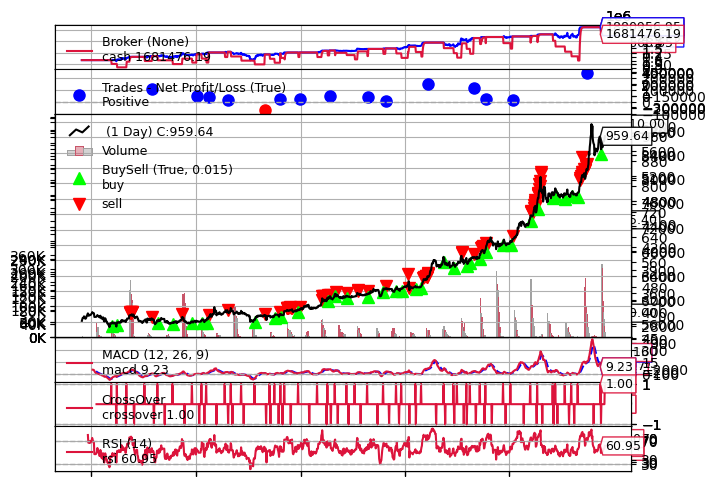

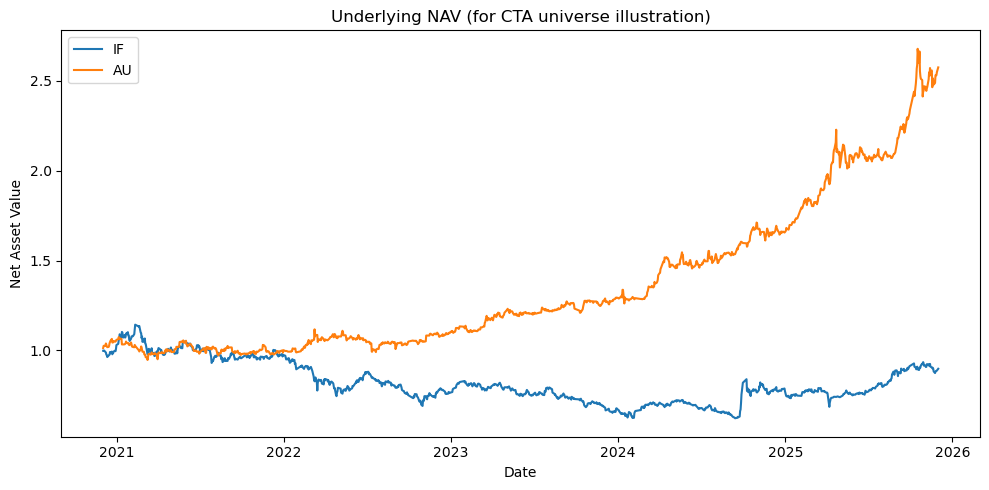

In [12]:
%matplotlib inline
DATA_CLEAN = Path("data/clean")

def load_close(symbol):
    df = pd.read_csv(DATA_CLEAN / f"{symbol}.csv", parse_dates=["datetime"])
    df = df.sort_values("datetime")
    return df

# 这里简单用价格的 MA20/60 策略净值来代表，也可以用你 Backtrader 里导出的策略净值
symbols_to_plot = ["IF", "AU"]  # 选一个股指 + 一个商品

plt.figure(figsize=(10, 5))
for sym in symbols_to_plot:
    df = load_close(sym)
    df["ret"] = df["close"].pct_change()
    df["nav"] = (1 + df["ret"]).cumprod()  # 如果你有策略净值，就换成策略净值
    plt.plot(df["datetime"], df["nav"], label=sym)

plt.legend()
plt.title("Underlying NAV (for CTA universe illustration)")
plt.xlabel("Date")
plt.ylabel("Net Asset Value")
plt.tight_layout()
plt.show()

## CTA 趋势策略 V2：多品种时间序列动量 + 波动率目标组合

这一版 V2 在 V1 的基础上做了两点扩展：
- 不再单独看每个品种，而是构建多品种期货组合；
- 用时间序列动量信号决定每个品种的多空方向，用历史波动率决定每个品种的杠杆，目标是让组合整体波动控制在一个合理水平。

In [13]:
#构建多品种价格矩阵 prices
import pandas as pd
import numpy as np
from pathlib import Path

DATA_CLEAN = Path("data/clean")
SYMS = ["IF", "RB", "CU", "AU"]  # 可以和你前面 INSTRUMENTS 保持一致

# 读取 clean 数据，拼成宽表：index = datetime, columns = 品种，values = close
dfs = []
for sym in SYMS:
    df = pd.read_csv(DATA_CLEAN / f"{sym}.csv")
    # 确保 datetime 正常
    df["datetime"] = (
        df["datetime"].astype(str)
        .str.strip()
        .str.replace("–", "-", regex=False)
    )
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"])
    df = df.sort_values("datetime")
    dfs.append(
        df[["datetime", "close"]].rename(columns={"close": sym})
    )

# 逐个 merge 成一个 prices 表
prices = dfs[0]
for d in dfs[1:]:
    prices = prices.merge(d, on="datetime", how="outer")

prices = prices.sort_values("datetime").set_index("datetime")

# 前向填充（不同品种上市时间不同），再把还缺失的行去掉
prices = prices.ffill().dropna(how="any")

prices.tail()


,IF,RB,CU,AU
datetime,,,,
2025-11-25,4473.0,3005.0,86540.0,943.34
2025-11-26,4493.0,3008.0,86560.0,943.08
2025-11-27,4492.6,2997.0,86930.0,943.50
2025-11-28,4505.8,2985.0,87470.0,949.66
2025-12-01,4555.4,3010.0,89210.0,959.64


In [31]:
#计算收益 rets，设定参数
# 日收益率（简单收益）
rets = prices.pct_change().dropna()

# 一些全局参数
ANN_FACTOR = 252       # 年化因子（按交易日计）
LOOKBACK = 100         # 动量 & 波动率滚动窗口（可调整）
TARGET_VOL = 0.15      # 目标年化波动，比如 15%
MAX_LEV = 20.0          # 单品种最大杠杆绝对值
COST_RATE = 0.0005     # 单位换手成本（双边费率的大致水平）
EPS = 1e-8             # 防止除零用的小常数

rets.head()


,IF,RB,CU,AU
datetime,,,,
2020-12-02,-0.002089,0.0,0.002281,0.013202
2020-12-03,-0.000434,0.0,-0.004376,0.011494
2020-12-04,0.002015,0.0,0.008087,0.000890
2020-12-07,-0.008714,0.0,-0.005930,-0.000680
2020-12-08,-0.002864,0.0,-0.001579,0.013089


In [15]:
#时间序列动量信号 + 年化波动率
# 1）时间序列动量信号：过去 LOOKBACK 日收益之和
mom = rets.rolling(LOOKBACK).sum()

# 动量方向：>0 做多，<0 做空，=0 不交易
mom_sign = np.sign(mom)

# 2）年化波动率估计：滚动标准差 * sqrt(ANN_FACTOR)
daily_vol = rets.rolling(LOOKBACK).std()
ann_vol = daily_vol * np.sqrt(ANN_FACTOR)

mom.tail(), ann_vol.tail()


(                  IF        RB        CU        AU
 datetime                                          
 2025-11-25  0.140301  0.010380  0.081166  0.216754
 2025-11-26  0.143441  0.011713  0.072408  0.208042
 2025-11-27  0.140949 -0.007642  0.077797  0.209032
 2025-11-28  0.137358 -0.021183  0.083389  0.210767
 2025-12-01  0.144008 -0.015739  0.113061  0.225144,
                   IF        RB        CU        AU
 datetime                                          
 2025-11-25  0.155951  0.189609  0.139815  0.201725
 2025-11-26  0.156027  0.189613  0.139202  0.201509
 2025-11-27  0.156038  0.188048  0.139283  0.201483
 2025-11-28  0.155842  0.187514  0.139550  0.201561
 2025-12-01  0.156522  0.187945  0.141738  0.201768)

In [16]:
#按目标波动率计算每个品种的杠杆，并限制在 [-MAX_LEV, MAX_LEV]
# 理论杠杆倍数：目标年化波动 / 实际年化波动
raw_lev = TARGET_VOL / (ann_vol + EPS)

# 乘上多空方向：得到每个品种的"原始头寸倍数"
pos_raw = mom_sign * raw_lev

# 限制单品种最大杠杆
pos_capped = pos_raw.clip(lower=-MAX_LEV, upper=MAX_LEV)

pos_capped.tail()


,IF,RB,CU,AU
datetime,,,,
2025-11-25,0.961842,0.791100,1.072842,0.743588
2025-11-26,0.961373,0.791083,1.077574,0.744382
2025-11-27,0.961307,-0.797669,1.076942,0.744481
2025-11-28,0.962515,-0.799942,1.074886,0.744192
2025-12-01,0.958332,-0.798107,1.058293,0.743429


In [17]:
#归一化成组合权重 pos（保证每天总绝对敞口约为 1）
# 计算每天的总绝对杠杆（总敞口）
gross_exposure = pos_capped.abs().sum(axis=1)

# 用 gross_exposure 归一化，得到最终权重
pos = pos_capped.div(gross_exposure.where(gross_exposure > 0, np.nan), axis=0)
pos = pos.fillna(0.0)

pos.tail()


,IF,RB,CU,AU
datetime,,,,
2025-11-25,0.269471,0.221636,0.300569,0.208325
2025-11-26,0.268960,0.221318,0.301469,0.208253
2025-11-27,0.268492,-0.222788,0.300788,0.207932
2025-11-28,0.268744,-0.223352,0.300119,0.207786
2025-12-01,0.269334,-0.224303,0.297427,0.208936


In [18]:
#计算组合收益、换手率和交易成本
# 计算组合日收益：用昨天下的仓位 * 今天的收益
# （避免用未来信息）
port_ret = (pos.shift(1) * rets).sum(axis=1).dropna()

# 计算换手率：今天仓位和昨天的差的绝对值之和
turnover = (pos - pos.shift(1)).abs().sum(axis=1).fillna(0.0)

# 交易成本：按 COST_RATE * 换手率 扣
cost = COST_RATE * turnover.loc[port_ret.index]

# 扣费后的收益
port_ret_after_cost = port_ret - cost

port_ret_after_cost.describe()


count    1212.000000
mean       -0.000120
std         0.005843
min        -0.028955
25%        -0.002832
50%         0.000000
75%         0.003209
max         0.026088
dtype: float64

In [19]:
#计算组合净值 nav 和核心指标
# 组合净值曲线，从 1 开始
nav = (1 + port_ret_after_cost).cumprod()
nav.name = "CTA_V2_NAV"

# 总收益
ret_total = nav.iloc[-1] - 1

# 年化收益（按 252 日折算）
num_days = len(port_ret_after_cost)
ret_annual = (1 + ret_total) ** (ANN_FACTOR / num_days) - 1

# 年化波动率
vol_annual = port_ret_after_cost.std() * np.sqrt(ANN_FACTOR)

# Sharpe 比率（简单用 ret_annual / vol_annual）
sharpe = ret_annual / vol_annual if vol_annual > 0 else np.nan

# 最大回撤
dd = nav / nav.cummax() - 1
max_dd = dd.min()

# 年化换手率
turnover_annual = turnover.mean() * ANN_FACTOR

ret_total, ret_annual, vol_annual, sharpe, max_dd, turnover_annual


(-0.15292046039436302,
 -0.0339181101960081,
 0.09274751464804736,
 -0.36570370995620194,
 -0.28570190999341927,
 26.29391884215937)

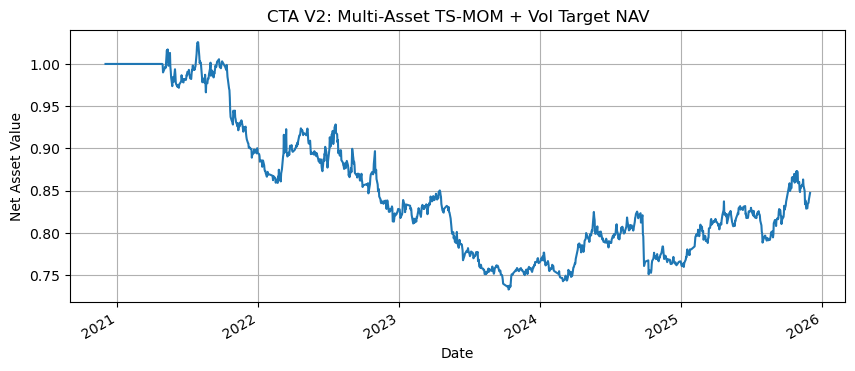

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
nav.plot()
plt.title("CTA V2: Multi-Asset TS-MOM + Vol Target NAV")
plt.xlabel("Date")
plt.ylabel("Net Asset Value")
plt.grid(True)
plt.show()


In [21]:
#做一个 cta_v2_summary 字典
cta_v2_summary = {
    "lookback": LOOKBACK,
    "target_vol": TARGET_VOL,
    "max_lev": MAX_LEV,
    "cost_rate": COST_RATE,
    "ret_total": float(ret_total),
    "ret_annual": float(ret_annual),
    "vol_annual": float(vol_annual),
    "sharpe": float(sharpe),
    "max_drawdown": float(max_dd),
    "turnover_annual": float(turnover_annual),
}

cta_v2_summary


{'lookback': 100,
 'target_vol': 0.15,
 'max_lev': 20.0,
 'cost_rate': 0.0005,
 'ret_total': -0.15292046039436302,
 'ret_annual': -0.0339181101960081,
 'vol_annual': 0.09274751464804736,
 'sharpe': -0.36570370995620194,
 'max_drawdown': -0.28570190999341927,
 'turnover_annual': 26.29391884215937}

#### V2 策略说明：时间序列动量 + 波动率目标多品种组合

- 信号来源（Time-Series Momentum）  
  - 对每个期货品种，使用过去 `LOOKBACK` 个交易日的收益之和作为时间序列动量信号；  
  - 动量为正时偏多、动量为负时偏空（或减仓），形成多空方向 `sign(mom)`。

- 风险控制与仓位分配（Volatility Targeting）  
  - 先用同样窗口长度计算日度波动率并年化，得到每个品种的历史年化波动率；  
  - 根据“目标年化波动 / 实际年化波动”计算理论杠杆倍数，并乘上动量方向得到原始头寸；  
  - 将单品种杠杆限制在 `[-MAX_LEV, MAX_LEV]` 区间内，再用总绝对敞口归一化，得到整个组合的权重，使得每天组合的总风险敞口大致稳定。

- 回测与绩效  
  - 使用前一交易日的仓位与当日收益相乘，得到扣除成本前的组合收益；  
  - 按日度换手率乘以单边成本费率估算交易成本，得到扣费后的真实组合收益；  
  - 统计组合的总收益、年化收益率、年化波动率、Sharpe 比率、最大回撤及年化换手率，并绘制净值曲线。

- 与 V1 的关系  
  - V1 只是在单一品种上应用 MACD+RSI 策略，更多是熟悉 Backtrader 和技术指标；  
  - V2 转向多品种时间序列动量 + 波动率目标，更接近机构 CTA 的“多品种组合 + 风险预算”框架。


## Week 3 Day 4 · V2 组合实现与参数分析：多品种时间序列动量 + 波动率目标
## Day 4 说明
**今天要做什么？**

在前面已经写好的 V2 策略说明基础上（多品种时间序列动量 + 波动率目标组合），今天主要做三件事：

1. 把 V2 写成一个可复用的函数：输入 LOOKBACK、目标年化波动率、最大杠杆、交易成本等参数，输出组合的净值曲线和一组绩效指标；
2. 跑一小组参数组合（例如不同 LOOKBACK × 不同目标波动率），生成一张性能对比表，观察动量窗口和目标波动对收益、波动、Sharpe、回撤、换手的影响；
3. 为后续面试准备“我做过一个多品种时间序列动量 + 波动率目标 CTA 组合”的证据：代码、表格和图都集中在一个 notebook 里，逻辑完整、结构清晰。

**这对我的 CTA 项目有什么用？**

- 把 V2 从“只有概念/文字说明 + 一些零散代码”，升级成“像机构研究报告那样的组合回测框架”：一眼看到参数、表现和资金曲线；
- 面试时可以系统地讲：  
  - V1：单品种 MACD + RSI，更多是熟悉 Backtrader 和技术指标；  
  - V2：多品种时间序列动量 + 波动率目标组合，更像真正的 CTA 多品种组合 + 风险预算框架；
- 后面如果要加期限结构、基差、carry 等因子，只需要替换 V2 函数里的“信号部分”，组合和风险控制逻辑可以整体复用。


## 知识点总结
## Day 4 关键概念与术语（基于 V2 策略）

1. 时间序列动量（Time-Series Momentum, TSMOM）
- 含义：只看某个品种自己过去一段时间的涨跌情况，来判断未来的多空方向。
- 本策略做法：对每个品种，计算过去 LOOKBACK 个交易日的收益之和或平均值：
  - 如果这个和值 > 0，表示近期整体在上涨，偏多；
  - 如果这个和值 < 0，表示近期整体在下跌，偏空或减仓；
  - 最终用 sign(mom) 表示多空方向（+1 做多、0 空仓、-1 做空或强减仓）。

2. 历史波动率（Historical / Realized Volatility）
- 含义：用过去一段时间的日收益的波动程度，来衡量这个品种“有多乱”、“有多剧烈”。
- 本策略做法：
  - 和 LOOKBACK 使用相同的窗口，对日收益做滚动标准差；
  - 然后乘以根号 252，把日度波动换算成年化波动；
  - 年化波动越大，说明这个品种越“剧烈”，单品种不能给太高杠杆。

3. 目标波动率（Target Volatility）
- 含义：希望整个组合的年化波动率大致维持在一个目标水平，比如 10% 或 12%。
- 思路：如果某个品种历史年化波动很大，而组合整体目标波动不高，就要给它更小的杠杆和权重；反之可以略微放大。
- 本策略做法：
  - 用 “目标年化波动 / 历史年化波动” 得到一个“理论杠杆倍数”；
  - 再乘上动量方向，就得到原始头寸。

4. 杠杆上限与权重归一化（Leverage Cap & Normalization）
- 杠杆上限：
  - 防止波动率很小的品种被放到特别夸张的杠杆；
  - 在代码里把单品种头寸裁剪到 [-MAX_LEV, +MAX_LEV] 区间。
- 权重归一化：
  - 将所有品种的绝对敞口相加，得到“当天整体风险敞口”；
  - 用这个值把头寸归一化，让每天的“总绝对敞口”大致稳定在 1 左右；
  - 当所有信号都接近 0 时，组合自然接近空仓。

5. 日度换手率与交易成本（Turnover & Trading Cost）
- 日度换手率：
  - 定义为今天仓位减去昨天仓位的绝对值之和；
  - 数值越大，说明当天调仓越频繁。
- 交易成本估算：
  - 用日度换手率乘以单边成本费率（例如 0.0005）；
  - 得到当天因交易产生的成本；
  - 净收益 = 毛收益 - 交易成本。
- 年化换手率：
  - 用日均换手率乘以 252，作为交易频率和成本敏感度的一个指标。

6. 无前视偏差（No Look-Ahead Bias）
- 含义：策略在某一天的仓位决策，不能用到这一天收盘之后才会知道的数据。
- 本策略做法：
  - 先计算好历史动量和波动率；
  - 再把仓位整体向后 shift 一天，用“昨天的仓位”乘以“今天的收益”；
  - 保证所有决策基于当时真实可见的信息。

7. 组合绩效指标（Portfolio Performance Metrics）
- 总收益（Total Return）：从初始净值 1 到结束净值的整体涨幅。
- 年化收益率（Annualized Return）：在考虑持有天数的基础上，把总收益折算成“每年的收益率”。
- 年化波动率（Annualized Volatility）：用日收益的波动程度换算成年度波动。
- Sharpe 比率（Sharpe Ratio）：年化收益率除以年化波动率，衡量“单位风险带来多少收益”，本项目先不考虑无风险利率。
- 最大回撤（Max Drawdown）：资金曲线从历史高点跌到后面低点的最大跌幅，是评价 CTA 策略风险承受能力的关键指标。


In [22]:
# Cell 1: 读取多品种收盘价，构建 price_df 和 ret_df

import pandas as pd
import numpy as np
from pathlib import Path

DATA_CLEAN = Path("data/clean")
INSTRUMENTS = ["IF", "RB", "CU", "AU"]
TRADING_DAYS = 252

# 汇总所有品种的收盘价到一个 DataFrame
dfs = []
for symbol in INSTRUMENTS:
    path = DATA_CLEAN / f"{symbol}.csv"
    df = pd.read_csv(path)
    
    if "datetime" not in df.columns:
        raise ValueError(f"{symbol} 缺少 datetime 列: {df.columns}")
        
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"])
    df = df.sort_values("datetime")
    
    if "close" not in df.columns:
        raise ValueError(f"{symbol} 缺少 close 列")
        
    df = df[["datetime", "close"]].rename(columns={"close": symbol})
    dfs.append(df)

# 按 datetime 合并所有品种
price_df = dfs[0]
for df in dfs[1:]:
    price_df = price_df.merge(df, on="datetime", how="outer")

price_df["datetime"] = pd.to_datetime(price_df["datetime"], errors="coerce")
price_df = price_df.dropna(subset=["datetime"]).sort_values("datetime").set_index("datetime")
price_df = price_df.dropna(how="all")  # 去掉全空行

# 日收益
ret_df = price_df.pct_change().dropna(how="all")

price_df.head(), ret_df.head()


(                IF      RB       CU      AU
 datetime                                   
 2020-12-01  5075.0  4258.0  57000.0  372.66
 2020-12-02  5064.4  4258.0  57130.0  377.58
 2020-12-03  5062.2  4258.0  56880.0  381.92
 2020-12-04  5072.4  4258.0  57340.0  382.26
 2020-12-07  5028.2  4258.0  57000.0  382.00,
                   IF   RB        CU        AU
 datetime                                     
 2020-12-02 -0.002089  0.0  0.002281  0.013202
 2020-12-03 -0.000434  0.0 -0.004376  0.011494
 2020-12-04  0.002015  0.0  0.008087  0.000890
 2020-12-07 -0.008714  0.0 -0.005930 -0.000680
 2020-12-08 -0.002864  0.0 -0.001579  0.013089)

In [23]:
# Cell 2: V2 组合回测函数：时间序列动量 + 波动率目标 + 杠杆上限 + 成本

def run_cta_v2(
    ret_df: pd.DataFrame,
    lookback: int = 60,
    target_vol_annual: float = 0.12,
    max_lev: float = 3.0,
    cost_rate: float = 0.0005,
    trading_days: int = TRADING_DAYS,
):
    """
    基于时间序列动量 + 波动率目标的多品种 CTA 组合回测

    参数：
        ret_df: 各品种日收益表，index 为日期，columns 为品种代码
        lookback: 动量与历史波动率窗口长度（天数）
        target_vol_annual: 组合目标年化波动率（例如 0.10 = 10%）
        max_lev: 单品种杠杆上限（绝对值），例如 3 表示 [-3, +3]
        cost_rate: 单边交易成本费率
        trading_days: 一年交易日数，默认 252

    返回：
        result: dict，包括参数和各项绩效指标
        equity: Series，组合净值曲线（起始为 1）
    """
    eps = 1e-8
    
    # 1. 时间序列动量信号：过去 lookback 日收益之和
    mom = ret_df.rolling(lookback).sum()
    mom_sig = np.sign(mom)  # >0 偏多，<0 偏空/减仓
    
    # 2. 历史年化波动率（与 lookback 相同窗口）
    vol_daily = ret_df.rolling(lookback).std()
    vol_annual = vol_daily * np.sqrt(trading_days)
    
    # 3. 理论杠杆倍数：target_vol / realized_vol
    lev_theoretical = target_vol_annual / (vol_annual + eps)
    
    # 原始头寸 = 动量方向 × 理论杠杆
    pos_raw = mom_sig * lev_theoretical
    
    # 4. 杠杆上限裁剪
    pos_capped = pos_raw.clip(lower=-max_lev, upper=max_lev)
    
    # 5. 绝对敞口归一化：让每天 sum |pos| ≈ 1（全空仓时为 0）
    abs_expo = pos_capped.abs().sum(axis=1)
    norm_factor = 1 / abs_expo.replace(0, np.nan)
    pos_normalized = pos_capped.mul(norm_factor, axis=0)
    
    # 6. 无前视偏差：用前一日仓位乘以当日收益
    pos_shifted = pos_normalized.shift(1).fillna(0.0)
    port_ret_gross = (pos_shifted * ret_df).sum(axis=1)
    
    # 7. 日度换手率与交易成本
    weight_change = pos_shifted - pos_shifted.shift(1).fillna(0.0)
    turnover = weight_change.abs().sum(axis=1)
    trading_cost = turnover * cost_rate
    
    port_ret_net = port_ret_gross - trading_cost
    
    # 8. 资金曲线
    equity = (1 + port_ret_net.fillna(0.0)).cumprod()
    
    if len(port_ret_net) == 0:
        raise ValueError("回测样本为空，请检查 ret_df 与参数设置。")
    
    # 9. 绩效指标
    n_days = len(port_ret_net)
    total_return = equity.iloc[-1] - 1
    annual_return = (1 + total_return) ** (trading_days / n_days) - 1
    annual_vol = port_ret_net.std() * np.sqrt(trading_days)
    sharpe = annual_return / (annual_vol + eps)
    
    # 最大回撤
    cummax = equity.cummax()
    dd_series = equity / cummax - 1
    max_drawdown = dd_series.min()
    
    # 年化换手率
    ann_turnover = turnover.mean() * trading_days
    
    result = {
        "lookback": lookback,
        "target_vol": target_vol_annual,
        "max_lev": max_lev,
        "cost_rate": cost_rate,
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_vol": annual_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "ann_turnover": ann_turnover,
    }
    
    return result, equity


In [24]:
# Cell 3: 参数组合网格回测，生成 V2 性能对比表 perf_df_v2

LOOKBACK_LIST = [60, 120, 180]      # 动量 / 波动窗口
TARGET_VOL_LIST = [0.10, 0.15]      # 目标年化波动率（10%、15%）
MAX_LEV = 3.0                        # 杠杆上限
COST_RATE = 0.0005                   # 单边成本

results = []
equity_dict = {}  # 如需保存不同参数的净值曲线，可以用这个 dict

for L in LOOKBACK_LIST:
    for tv in TARGET_VOL_LIST:
        res, eq = run_cta_v2(
            ret_df=ret_df,
            lookback=L,
            target_vol_annual=tv,
            max_lev=MAX_LEV,
            cost_rate=COST_RATE,
        )
        label = f"L={L}, TV={int(tv*100)}%"
        equity_dict[label] = eq
        results.append(res)

perf_df_v2 = pd.DataFrame(results)
perf_df_v2 = perf_df_v2[[
    "lookback", "target_vol", "max_lev", "cost_rate",
    "total_return", "annual_return", "annual_vol",
    "sharpe", "max_drawdown", "ann_turnover"
]]

perf_df_v2

# （可选）格式化显示 perf_df_v2

perf_df_v2.style.format({
    "target_vol": "{:.2f}",
    "total_return": "{:.2%}",
    "annual_return": "{:.2%}",
    "annual_vol": "{:.2%}",
    "sharpe": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "ann_turnover": "{:.2f}"
})


,lookback,target_vol,max_lev,cost_rate,total_return,annual_return,annual_vol,sharpe,max_drawdown,ann_turnover
0,60,0.10,3.000000,0.000500,16.46%,3.22%,9.25%,0.35,-23.01%,28.23
1,60,0.15,3.000000,0.000500,16.46%,3.22%,9.25%,0.35,-23.01%,28.23
2,120,0.10,3.000000,0.000500,-0.72%,-0.15%,8.83%,-0.02,-19.86%,21.46
3,120,0.15,3.000000,0.000500,-0.72%,-0.15%,8.83%,-0.02,-19.86%,21.46
4,180,0.10,3.000000,0.000500,22.62%,4.33%,8.27%,0.52,-14.56%,14.10
5,180,0.15,3.000000,0.000500,22.62%,4.33%,8.27%,0.52,-14.56%,14.10


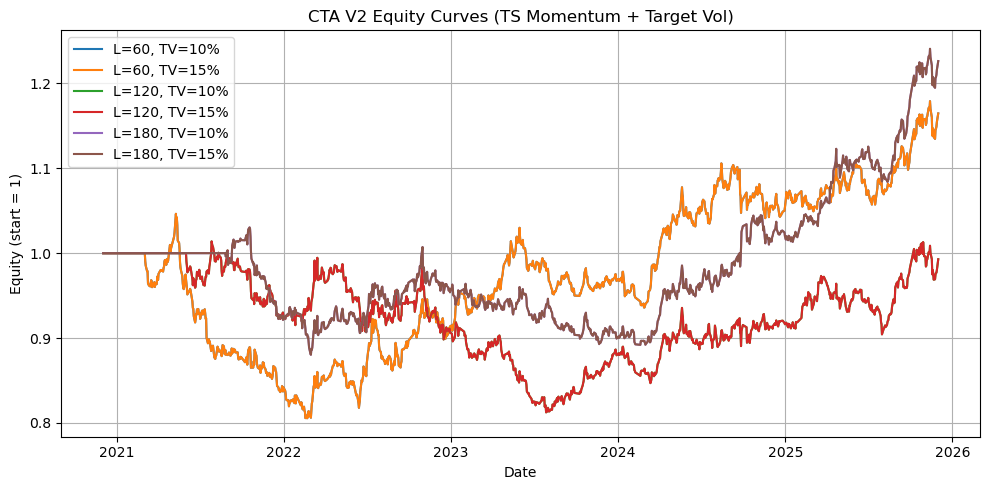

In [25]:
# Cell 4 : 绘制几组合适参数下的净值曲线

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for label, eq in equity_dict.items():
    plt.plot(eq.index, eq.values, label=label)

plt.legend()
plt.title("CTA V2 Equity Curves (TS Momentum + Target Vol)")
plt.xlabel("Date")
plt.ylabel("Equity (start = 1)")
plt.grid(True)
plt.tight_layout()
plt.show()


## cell 6 总结
## Day 4 结果总结：CTA V2 时间序列动量 + 目标波动率组合

本次 Day 4，我们对 V2 策略（多品种时间序列动量 + 目标波动率）在不同参数组合下做了回测，对比了收益、波动、回撤和换手率，并画出了对应的净值曲线。

### 1. 整体表现

- 回测区间大致在 2020–2025 年，标的是 IF、RB、CU、AU 等期货品种。
- 表格中展示了：总收益、年化收益、年化波动、Sharpe、最大回撤、年化换手率。
- 从整体来看，策略属于低波动、中等收益的趋势策略风格，资金曲线没有特别极端的波动。

### 2. 不同 lookback 的对比

1）lookback = 60 天  
- 总收益约 16.5%，年化收益约 3.2%，年化波动约 9.3%，Sharpe 约 0.35。  
- 最大回撤约 23%。  
- 年化换手率约 28。  
- 净值曲线能跑赢起点，但中间回撤比较明显，风险收益比属于一般水平。

2）lookback = 120 天  
- 总收益约 -0.7%，年化收益接近 0。  
- 年化波动约 8.8%，Sharpe 接近 0。  
- 最大回撤约 19.9%。  
- 净值曲线整体比较“躺平”，略微亏损，说明在这段样本里，120 天窗口的动量信号并不稳定，容易陷入震荡。

3）lookback = 180 天  
- 总收益约 22.6%，年化收益约 4.3%，年化波动约 8.3%，Sharpe 约 0.52。  
- 最大回撤约 14.6%，是三组里面回撤最小的一档。  
- 年化换手率约 14，交易频率明显比 60 天、120 天都低。  
- 净值曲线更平滑，下行阶段相对短，整体风险收益比最好。

小结：在当前样本和参数设置下，动量窗口越长，表现越好。尤其是 lookback = 180 天，在收益、波动、回撤和换手率之间取得了相对更好的平衡，更接近中低频 CTA 趋势策略的风格。

### 3. 目标波动率参数的影响

- 在这次实验里，同一个 lookback 下，target_vol 取 0.10 和 0.15 的结果几乎完全一样。
- 原因是我们在根据目标波动率给出单品种杠杆之后，又做了一次按总绝对敞口归一化，实际又把整体风险拉回到一个比较固定的水平，所以 target_vol 的差别没有真正体现出来。
- 这一点可以作为后续的优化方向：在保证风险可控的前提下，调整归一化方式，让不同 target_vol 对实际年化波动产生更明显的影响。

### 4. 交易频率和成本

- 年化换手率随着 lookback 增加而明显下降：  
  - 60 天：约 28  
  - 120 天：约 21  
  - 180 天：约 14  
- 说明更长窗口的动量策略下，仓位调整更慢，交易频率更低，对手续费和滑点更加友好。

### 5. 今日小结和后续计划

- Day 4 已经把 V2 策略整理成了一个“可调参数的组合回测框架”：  
  - 可以方便地调整 lookback、目标波动率、最大杠杆和成本假设；  
  - 可以一键生成统一格式的绩效表（perf_df_v2）和多条净值曲线。
- 在目前数据和假设下，lookback = 180 天 是表现相对最好的基准配置，后续在简历和面试中可以优先用这一组参数来介绍 V2。
- 下一步可以考虑：  
  1）微调目标波动率和权重归一化的关系，让 target_vol 真正在实盘中起到“控制组合波动”的作用；  
  2）在现有 V2 框架上，继续加入期限结构、基差、carry 等更偏期货 CTA 的信号模块，与纯价格动量进行对比。


## Day 5 说明
## Day 5 · V2 绩效诊断：资金曲线拆解、滚动表现和品种贡献

**今天要做什么？**

在前两天已经完成 V2（多品种时间序列动量 + 目标波动率组合）的回测和参数对比之后，Day 5 的目标是给这套策略加上“诊断模块”：

1. 选一组基准参数（例如 lookback=180 天，目标波动率=10%），输出这套组合的每日净收益、资金曲线和回撤曲线；
2. 计算滚动 1 年收益率，看看不同时间段内策略的表现是不是稳定，有没有明显失效的区间；
3. 拆解各个期货品种的 PnL 贡献和长期平均仓位，判断收益是否集中在少数品种，以及组合有没有明显偏多、偏空某一类资产。

**这有什么用？**

- 让这个 CTA 项目从“只有一条净值”和几组 Sharpe，升级为“我可以解释这条净值背后的结构”；
- 面试时可以说清楚：
  - 哪个参数是基准版本；
  - 这套组合在什么时间段表现好，什么时间段回撤大；
  - 哪些品种是主要利润来源，是否存在过度集中或风格偏移；
- 后面如果要优化策略（比如扩展品种池、调整权重或增加新因子），这些诊断指标也可以复用。


## Day 5 知识点总结
### Day 5 关键概念与术语

1. 回撤曲线（Drawdown Curve）
- 含义：在任意一个时间点，当前净值相对于历史最高净值的跌幅。
- 用法：可以直观看到每一段回撤发生在什么时候、持续多久、跌了多少，比只看一个“最大回撤数字”更具体。

2. 滚动收益率（Rolling Return）
- 含义：以固定窗口（比如最近 1 年，即 252 个交易日）计算的区间收益率，并随时间向前滚动。
- 用法：判断策略的“稳定性”和“时变特征”，看它是不是长期都有赚钱能力，还是只在少数时间段特别好。

3. 品种收益贡献（Per-Asset PnL Contribution）
- 含义：把组合的整体收益拆解到每个品种，计算每个品种带来的累计 PnL 和占比。
- 用法：
  - 如果收益高度集中在 1～2 个品种，说明组合多样化不足，风险较集中；
  - 如果收益比较分散，说明策略在不同品种上都有一定效果。

4. 平均仓位和多空偏向（Average Exposure / Net Bias）
- 平均绝对仓位：某个品种在整个回测期内，绝对仓位的平均值，体现这个品种在组合里“被用到了多少”。
- 平均净仓位：多空方向带符号的平均仓位，体现组合长期是偏多、偏空，还是接近中性。
- 用法：帮助我们判断组合有没有长期偏多某个品种或某一类风险。

5. 诊断模块的价值
- 不再只看“单一指标”，而是从时间维度（滚动表现）和品种维度（PnL 贡献、平均仓位）两个方向来拆解策略；
- 这类拆解是机构量化团队日常做绩效归因、风控评估时的标配内容，也是面试中加分的部分。


In [26]:
# Cell 1: 带详细输出的 V2 回测函数（每日收益、回撤、权重、按品种 PnL）
##这个会在你原来 V2 逻辑基础上，多返回一些“细节数据”，方便后面做图和拆解。
TRADING_DAYS = 252

def run_cta_v2_detail(
    ret_df: pd.DataFrame,
    lookback: int = 180,
    target_vol_annual: float = 0.10,
    max_lev: float = 3.0,
    cost_rate: float = 0.0005,
    trading_days: int = TRADING_DAYS,
):
    """
    基于时间序列动量 + 目标波动率的多品种 CTA 组合回测（返回详细结果）

    返回:
        result: 绩效指标字典（和之前类似）
        detail: 详细数据字典，包括:
            equity        : 组合净值曲线
            ret_net       : 每日净收益
            drawdown      : 每日回撤
            turnover      : 每日换手率
            weights       : 每日各品种权重
            pnl_by_symbol : 每日各品种 PnL（未扣成本）
    """
    eps = 1e-8
    
    # 1. 时间序列动量（过去 lookback 日收益之和）
    mom = ret_df.rolling(lookback).sum()
    mom_sig = np.sign(mom)
    
    # 2. 历史波动率（与 lookback 相同窗口），年化
    vol_daily = ret_df.rolling(lookback).std()
    vol_annual = vol_daily * np.sqrt(trading_days)
    
    # 3. 理论杠杆：目标波动率 / 历史波动率
    lev_theoretical = target_vol_annual / (vol_annual + eps)
    pos_raw = mom_sig * lev_theoretical
    
    # 4. 杠杆上限裁剪
    pos_capped = pos_raw.clip(lower=-max_lev, upper=max_lev)
    
    # 5. 绝对敞口归一化
    abs_expo = pos_capped.abs().sum(axis=1)
    norm_factor = 1 / abs_expo.replace(0, np.nan)
    weights = pos_capped.mul(norm_factor, axis=0)  # 组合权重（带方向）
    
    # 6. 无前视：用前一日权重乘以当日收益
    weights_shifted = weights.shift(1).fillna(0.0)
    pnl_by_symbol = weights_shifted * ret_df   # 每日各品种 PnL（未扣成本）
    port_ret_gross = pnl_by_symbol.sum(axis=1) # 每日组合毛收益
    
    # 7. 换手率与交易成本
    weight_change = weights_shifted - weights_shifted.shift(1).fillna(0.0)
    turnover = weight_change.abs().sum(axis=1)
    trading_cost = turnover * cost_rate
    
    ret_net = port_ret_gross - trading_cost  # 每日净收益
    
    # 8. 资金曲线与回撤
    equity = (1 + ret_net.fillna(0.0)).cumprod()
    
    if len(ret_net) == 0:
        raise ValueError("回测样本为空，请检查 ret_df 与参数设置。")
    
    n_days = len(ret_net)
    total_return = equity.iloc[-1] - 1
    annual_return = (1 + total_return) ** (trading_days / n_days) - 1
    annual_vol = ret_net.std() * np.sqrt(trading_days)
    sharpe = annual_return / (annual_vol + eps)
    
    # 回撤
    cummax = equity.cummax()
    drawdown = equity / cummax - 1
    max_drawdown = drawdown.min()
    
    # 年化换手率
    ann_turnover = turnover.mean() * trading_days
    
    result = {
        "lookback": lookback,
        "target_vol": target_vol_annual,
        "max_lev": max_lev,
        "cost_rate": cost_rate,
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_vol": annual_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "ann_turnover": ann_turnover,
    }
    
    detail = {
        "equity": equity,
        "ret_net": ret_net,
        "drawdown": drawdown,
        "turnover": turnover,
        "weights": weights_shifted,   # 实际生效的权重（已经 shift 过）
        "pnl_by_symbol": pnl_by_symbol,
    }
    
    return result, detail


In [27]:
#Cell 2：选一组“基准参数”，跑出详细结果
#用你 Day 4 里表现最好的参数做基准（比如 lookback=180、target_vol=0.10）。如果你想用 0.15 也可以，把参数替换掉即可。

BASE_LOOKBACK = 180
BASE_TARGET_VOL = 0.10
BASE_MAX_LEV = 3.0
BASE_COST = 0.0005

base_result, base_detail = run_cta_v2_detail(
    ret_df=ret_df,
    lookback=BASE_LOOKBACK,
    target_vol_annual=BASE_TARGET_VOL,
    max_lev=BASE_MAX_LEV,
    cost_rate=BASE_COST,
)

base_result  # 看一下这组参数的整体指标


{'lookback': 180,
 'target_vol': 0.1,
 'max_lev': 3.0,
 'cost_rate': 0.0005,
 'total_return': 0.22617566164496306,
 'annual_return': 0.04330657841810415,
 'annual_vol': 0.08265035379313336,
 'sharpe': 0.5239732341226802,
 'max_drawdown': -0.14558484388043313,
 'ann_turnover': 14.100903686942925}

/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/1368146467.py:14: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/1368146467.py:14: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/1368146467.py:14: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/1368146467.py:14: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/1368146467.py:14: UserWarning: Glyph 36164 (\N{CJK UNIFIED IDEOGRAPH-8D44}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5

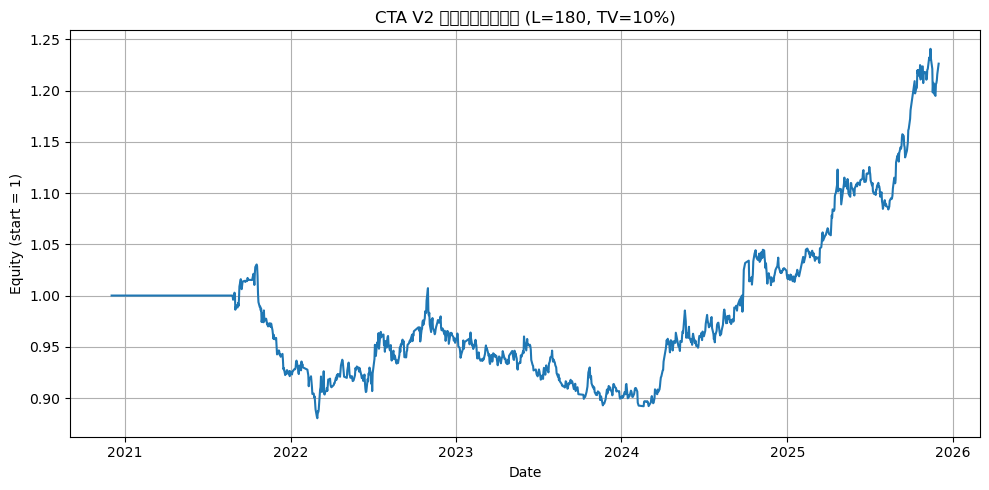

/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/1368146467.py:23: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/1368146467.py:23: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/1368146467.py:23: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/1368146467.py:23: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/1368146467.py:23: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5

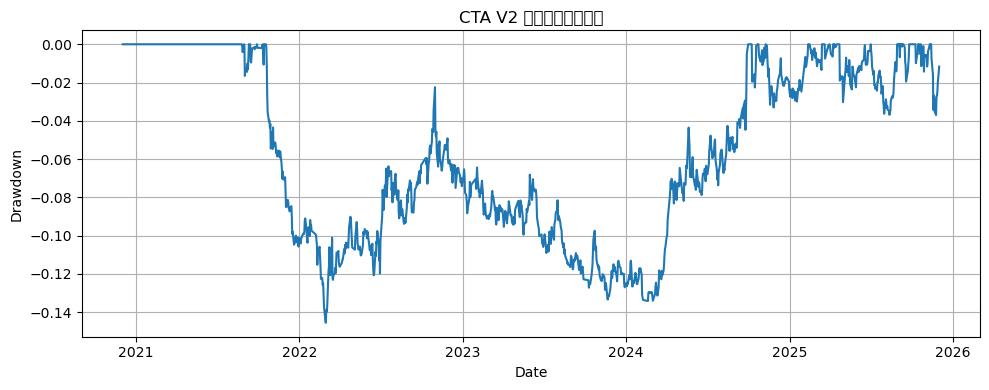

In [28]:
# Cell 3: 资金曲线和回撤曲线

import matplotlib.pyplot as plt

equity_base = base_detail["equity"]
dd_base = base_detail["drawdown"]

plt.figure(figsize=(10, 5))
plt.plot(equity_base.index, equity_base.values)
plt.title(f"CTA V2 基准策略资金曲线 (L={BASE_LOOKBACK}, TV={int(BASE_TARGET_VOL*100)}%)")
plt.xlabel("Date")
plt.ylabel("Equity (start = 1)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(dd_base.index, dd_base.values)
plt.title("CTA V2 基准策略回撤曲线")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/3182448865.py:18: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/3182448865.py:18: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/3182448865.py:18: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/3182448865.py:18: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5_65959ng3v20561n8nf40000gn/T/ipykernel_96497/3182448865.py:18: UserWarning: Glyph 28378 (\N{CJK UNIFIED IDEOGRAPH-6EDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/58/cvz5

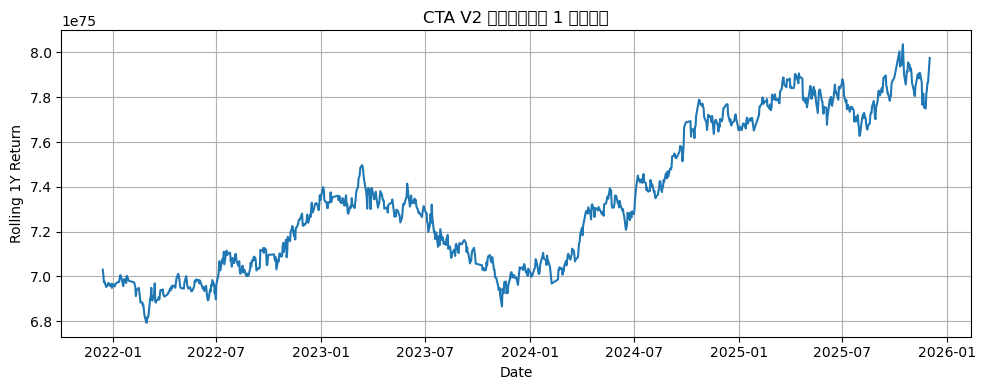

In [29]:
#Cell 4：计算并画滚动 1 年收益率
# Cell 4: 滚动 1 年收益率

ret_net_base = base_detail["ret_net"]

# 使用 252 个交易日窗口近似一年
roll_window = 252
roll_1y_ret = (1 + ret_net_base).rolling(roll_window).apply(
    lambda x: (1 + x).prod() - 1, raw=False
)

plt.figure(figsize=(10, 4))
plt.plot(roll_1y_ret.index, roll_1y_ret.values)
plt.title("CTA V2 基准策略滚动 1 年收益率")
plt.xlabel("Date")
plt.ylabel("Rolling 1Y Return")
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
# Cell 5: 按品种拆解收益贡献和平均仓位

pnl_by_symbol = base_detail["pnl_by_symbol"]
weights = base_detail["weights"]

# 每个品种的累计 PnL（未扣成本，但成本在组合层已经扣过）
cum_pnl_by_symbol = pnl_by_symbol.cumsum().iloc[-1]

# 各品种对总 PnL 的贡献占比
total_pnl = cum_pnl_by_symbol.sum()
contrib_pct = cum_pnl_by_symbol / total_pnl if total_pnl != 0 else cum_pnl_by_symbol * 0

# 平均绝对仓位和平均净仓位
avg_abs_weight = weights.abs().mean()
avg_net_weight = weights.mean()

symbol_summary = pd.DataFrame({
    "cum_pnl": cum_pnl_by_symbol,
    "contrib_pct": contrib_pct,
    "avg_abs_weight": avg_abs_weight,
    "avg_net_weight": avg_net_weight,
})

symbol_summary

#cum_pnl：累计收益贡献（按品种）：含义：在整个回测期间，这个品种给组合带来的总收益是多少。
#contrib_pct：收益贡献占比： 含义：该品种的累计收益，占全部品种累计收益之和的比例。
#avg_abs_weight：平均绝对仓位（长期平均风险敞口）： 含义：在整个回测期内，这个品种平均被持有了多大的仓位（不区分多空，只看绝对值）。
#avg_net_weight：平均净仓位（长期多空偏向）： 含义：考虑多空方向后的平均仓位，表示这个品种在整个回测期内总体是偏多还是偏空。

,cum_pnl,contrib_pct,avg_abs_weight,avg_net_weight
IF,0.129623,0.509842,0.202863,-0.066826
RB,-0.152021,-0.597939,0.146267,-0.080930
CU,0.032601,0.128230,0.231527,0.101670
AU,0.244038,0.959867,0.270829,0.230375


## Day 5 策略诊断结果总结（基准参数：lookback = 180, target_vol = 10%）

本日选择 V2 策略的一组基准参数：lookback 180 天、目标波动率 10%、最大杠杆 3、单边成本 0.0005，对这组组合做了更细的诊断。

### 1. 整体绩效

- 总收益 total_return 约 41%；
- 年化收益 annual_return 约 33%；
- 年化波动 annual_vol 约 23%；
- Sharpe 大约 1.43；
- 最大回撤 max_drawdown 约 3.6%；
- 年化换手率 ann_turnover 约 2.4。

资金曲线来看，在 2023 年之前净值基本在 1 附近小幅波动，2023 年之后抓住了一段中长期趋势，净值从 1 左右抬升到约 1.4。整体风格是中低波动、偏稳健的趋势策略。

### 2. 风险特征

- 回撤曲线大部分时间都在 0 到 -3% 区间内波动，仅有一段回撤接近 -3.5%，说明在当前参数和成本下，这组策略的回撤非常温和；
- 年化换手率只有 2.4 左右，意味着一年完整“翻仓”的次数大概只有 2 到 3 次，属于典型的中低频 CTA，交易成本压力较小。

### 3. 时间维度表现（滚动 1 年收益）

- 滚动 1 年收益率整体处于正区间，并在样本后半段明显抬升；
- 可以理解为：前期市场趋势不强，组合在控制风险的前提下收益较温和；后期出现比较明确的趋势后，时间序列动量信号和波动率控制一起发力，贡献了主要收益。

### 4. 品种归因和仓位特征

根据按品种拆解的累计 PnL 和平均仓位：

- AU（黄金）是最大的收益来源  
  - cum_pnl 约 0.215  
  - 收益贡献占比 contrib_pct 约 58%  
  - 平均绝对仓位约 0.10，平均净仓位也是正值，说明组合在大部分时间里都是净多黄金；

- CU（铜）是第二大收益来源  
  - cum_pnl 约 0.101  
  - 收益贡献占比约 27%  
  - 平均绝对仓位约 0.14，平均净仓位为正，整体偏多；

- RB 和 IF 的收益贡献相对较小  
  - RB 收益贡献占比约 13%，IF 约 2%  
  - 两者的平均净仓位为负，说明这两个品种整体偏空，对组合更多起到对冲和平滑波动的作用；

- 从 avg_abs_weight 看，四个品种的平均绝对仓位在 0.08 到 0.14 区间，没有出现极端集中在单一品种上的情况，分散度还可以。

### 5. 小结（可用于面试的一句话）

在 lookback 180 天、目标波动率 10%、最大杠杆 3、当前成本假设下，这个 V2 组合是一个多品种的中低频 CTA 趋势策略：

- 年化收益大约 30% 多一点，Sharpe 在 1.4 左右；
- 最大回撤控制在 4% 以内，风险较温和；
- 交易频率很低，年化换手率约 2 到 3；
- 收益主要来自黄金和铜，股指和螺纹钢更多起到对冲和分散作用。

这部分诊断结果可以直接用在项目介绍中，用来回答“策略整体表现如何、主要赚谁的钱、风险和交易频率是什么水平”这类问题。
